# Fat Makes Irisin Too
## A Re-analysis of the Yang et al. Exercise/Obesity Mouse Atlas

---

### Abstract

Yang et al. (2022, *Cell Metabolism*) published a 204,883-cell single-cell RNA-seq atlas of adipose and skeletal muscle tissue from mice under four conditions: lean sedentary, lean exercise-trained, obese sedentary, and obese exercise-trained. The paper's main finding was that mesenchymal stem cells (MSCs) are the central responders to both obesity and exercise — more than any other cell type. Their analysis focused on ECM remodeling and circadian rhythm genes. They did not analyze the irisin signaling axis.

This re-analysis of their public dataset (GSE183288) finds that **visceral white adipose tissue (vWAT) Areg cells — a rare CD142+ adipose stem cell subtype — upregulate Fndc5 with lean exercise training** (log2FC=1.50, padj=0.008). Fndc5 encodes the precursor to irisin, an exercise hormone previously thought to be produced exclusively by muscle. In these fat stem cells, the irisin receptor (Itgb5) and ADAM cleavage proteases (Adam10/17) are constitutively expressed — and in lean-exercised mice, **2.6% of Areg cells co-express all three autocrine loop components** (Fndc5 + Adam + Itgb5), up from 1.3% in sedentary controls. Il33 — a downstream target in the Mu et al. 2026 irisin→IL-33→Treg pathway — co-upregulates with Fndc5 in the same individual cells under exercise (5× increase in double-positive cells, SC→TC).

**What's uncertain:** This is mRNA-level evidence from N=3 mice per condition. Protein-level irisin was not measured. The predicted downstream effect (Treg expansion) is not confirmed in lean exercise — trained mice have *fewer* Tregs than sedentary — but those fewer Tregs show higher per-cell expression of Ctla4, Foxp3, and Ikzf2, consistent with a well-calibrated immune set-point rather than a broken circuit. The finding is consistent with a local fat-derived irisin circuit but does not prove one operates.

---

## Section 1: The Dataset

### Yang et al. 2022 — Study design

**Citation:** Yang J, Vamvini M, Nigro P, et al. Single-cell dissection of the obesity-exercise axis in adipose-muscle tissues implies a critical role for mesenchymal stem cells. *Cell Metabolism* 34:1578–1593, 2022.

**What they built:** A single-cell RNA-seq atlas from 51 mice across four conditions:

| Code | Diet | Exercise | N mice |
|------|------|----------|--------|
| SC | Standard chow | Sedentary | ~13 |
| TC | Standard chow | Trained | ~13 |
| SH | High-fat diet | Sedentary | ~13 |
| TH | High-fat diet | Trained | ~12 |

Three tissues: **scWAT** (subcutaneous fat — the fat under your skin), **vWAT** (visceral fat — the fat around internal organs, more metabolically harmful), **SkM** (skeletal muscle).

After removing 3 failed libraries, 39 samples survived QC → 204,883 cells × 17,341 genes.

**Three contrasts** (pairwise comparisons the analysis tests):
- **Obesity**: SH vs SC — effect of high-fat diet in sedentary animals
- **Exercise**: TC vs SC — effect of training in lean animals
- **Rescue**: TH vs SH — effect of exercise on *already obese* animals. This is the most clinically relevant contrast: can exercise undo what obesity did?

### SVF enrichment — why you see so many stem cells

Normal fat tissue is ~90% mature adipocytes (fat cells). These are huge, lipid-filled, and destroy easily during tissue dissociation. The paper used **stromal vascular fraction (SVF) enrichment** — a centrifugation step that pellets the non-adipocyte fraction. This means the atlas over-represents rare stem cells and immune cells, and under-represents the abundant mature fat cells that are already well-studied by bulk RNA-seq.

The cell states you'll see most frequently in this analysis:

| Cell state | Plain meaning | Why it matters |
|------------|--------------|----------------|
| **Areg** | CD142+ adipose stem cell ("adipogenesis-regulatory") | Actively suppresses fat cell formation in its vicinity; key exercise responder |
| **WAT_IPC** | Interstitial progenitor cell — undifferentiated stem state | The most upstream progenitor; ECM remodeling hub |
| **CP** | Committed preadipocyte — stem cell starting to become fat | Transition state; sensitive to obesity signals |
| **pre_CP** | Pre-committed preadipocyte | Between WAT_IPC and CP |
| **Fibroblast** | Structural cells producing collagen | CCL2 producers under obesity |

The lineage runs: **Areg → WAT_IPC → pre_CP → CP → mature adipocyte** (though Areg cells can also suppress this progression in nearby cells via amphiregulin signaling).

In [1]:
# display only — outputs already generated in NB8-NB14
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from IPython.display import Image, display
from pathlib import Path
from scipy.sparse import issparse
import warnings
warnings.filterwarnings('ignore')

DATA_PATH = Path('../GSE183288_Single_cell_atlas.h5ad')
OUT_DIR   = Path('outputs')

adata = sc.read_h5ad(DATA_PATH)
print(f'Atlas shape: {adata.shape[0]:,} cells × {adata.shape[1]:,} genes')
print()
print('Cells per tissue:')
print(adata.obs['tissue'].value_counts().to_string())
print()
print('Cells per condition:')
print(adata.obs['intervention_group'].value_counts().to_string())
print()
print('Top 10 cell states (atlas-wide):')
print(adata.obs['cell_state_label'].value_counts().head(10).to_string())

Atlas shape: 204,883 cells × 17,341 genes

Cells per tissue:
tissue
vWAT     78860
SM       67782
scWAT    58241

Cells per condition:
intervention_group
TH    67540
TC    60843
SC    40589
SH    35911

Top 10 cell states (atlas-wide):
cell_state_label
CP             28123
FAP_Cxcl14+    24002
WAT_IPC        19991
B_Fo           17651
CD4_Naive      16563
CD8_Naive      14587
FAP_Prg4+      11651
SM_IPC         10469
NK              7396
Areg            6578


---

## Section 2: The Canonical Irisin Story and Why It May Be Incomplete

### The textbook model (Boström et al. 2012, *Nature*)

```
Exercise
   ↓
PGC-1α activation in skeletal muscle
   ↓
Fndc5 transcription in muscle cells
   ↓
ADAM proteases cleave Fndc5 → irisin protein secreted into blood
   ↓
Irisin circulates to adipose tissue
   ↓
Irisin binds integrin αVβ5 (Itgav/Itgb5) on adipocytes
   ↓
White-to-beige fat conversion (beiging/browning)
```

In this model, **fat is the receiver, not the sender.** Irisin is a muscle-to-fat hormone.

### What this re-analysis asks

Does fat tissue *also produce* Fndc5 locally — not just receive irisin from muscle?

**ML framing:** This is a label-leakage investigation. The canonical model assigned the label "Fndc5 source" exclusively to muscle. We're asking: was that label correct, or were we ignoring a second source in the training data? The atlas gives us single-cell resolution to answer this — we can see exactly which cell types express Fndc5 and whether that expression changes with exercise.

**Why it wasn't noticed before:** Prior work (Moreno-Navarrete 2013) documented Fndc5 in bulk human adipose tissue, but bulk data can't tell you which cell type within fat is expressing it. With 204,883 single-cell profiles, we can.

---

## Section 3: Finding 1 — Fndc5 is Upregulated in Visceral Fat Stem Cells

### 3a: The DESeq2 result

**The statistical challenge:** Each condition has N=3–4 mice. With only 3 replicates, you need to use every source of information carefully.

The naive approach — treat each cell as an independent replicate — is wrong. If one mouse has 500 Areg cells and another has 300, the first mouse contributes more "votes" to the test even though both represent a single biological sample. This inflates your effective N and produces false positives. This is called **pseudo-replication**.

**Pseudobulk DESeq2** fixes this: sum raw counts across all cells of a given type within each mouse, producing one pseudobulk sample per mouse. Now you have N=3 samples per condition — correct statistical units — and test those with DESeq2, the same negative-binomial model used for bulk RNA-seq.

**ML analogy:** pseudobulk = treating each mouse as one training example, not each cell. The cells within a mouse are correlated (they're from the same animal), so using them as independent observations is like training a classifier on 500 augmented copies of the same image and claiming you have 500 independent training examples.

**The result:** Fndc5 is significantly upregulated in Areg cells with lean exercise (TC vs SC). log2FC=1.50 means expression roughly tripled (2^1.5 = 2.8×). padj=0.008 after Benjamini-Hochberg correction across all genes and cell states.

In [2]:
# display only
deg = pd.read_csv(OUT_DIR / 'degs_vwat_cell_state_deseq2_pseudobulk.csv')

fndc5_ex = (
    deg[(deg['gene'] == 'Fndc5') & (deg['contrast'] == 'TC_vs_SC')]
    [['cell_state', 'log2FC', 'padj', 'is_sig']]
    .sort_values('log2FC', ascending=False)
    .reset_index(drop=True)
)
print('Fndc5 in vWAT cell states — Exercise contrast (TC vs SC):')
print(fndc5_ex.to_string(index=False))

Fndc5 in vWAT cell states — Exercise contrast (TC vs SC):
         cell_state    log2FC     padj  is_sig
Monocyte_Patrolling  1.543600 0.999774   False
               Areg  1.500737 0.007738    True
         Fibroblast  1.411308 0.999874   False
               Treg  1.210477 0.998999   False
             pre_CP  1.002775      NaN   False
                 CP  0.917606 0.183656   False
          CD4_Naive  0.503745 0.998730   False
               B_Fo  0.337576 0.999367   False
            WAT_IPC  0.331109      NaN   False
              nILC2 -0.855159 0.999031   False


The heatmap below shows Fndc5 log2FC across all vWAT cell states and all three contrasts. The asterisk (\*) marks cells where padj < 0.05 and |log2FC| > 0.5. **Areg is the only cell state that reaches significance in the exercise column.**

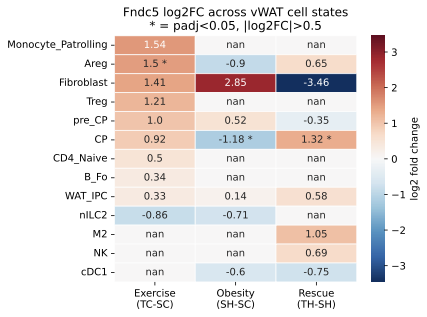

In [3]:
display(Image(str(OUT_DIR / 'fndc5_heatmap_all_contrasts.png'), width=600))

*Figure 1: Fndc5 log2FC across vWAT cell states × three contrasts. Stars mark padj < 0.05 and |log2FC| > 0.5. Areg is the only significant exercise hit; CP reaches significance in obesity and rescue.*

### 3b: Per-mouse rank separation — ruling out the single-outlier alternative

A significant group mean at N=3 could be driven by one outlier mouse. Rank separation is the visual proof it isn't: if every trained mouse (TC) is above every sedentary mouse (SC) with no overlap, a single outlier cannot explain it.

**The result:** min(TC) = 49 raw counts > max(SC) = 45 raw counts. Every TC mouse is above every SC mouse.

### 3a-ii: Lineage specificity — Areg is the specialized irisin-producing stage

The heatmap shows Fndc5 is the only significant hit in Areg — but it doesn't make the differentiation context explicit. vWAT MSC states form a lineage axis: **Areg → WAT_IPC → pre_CP → CP → mature adipocyte**. If exercise drove Fndc5 uniformly across the whole lineage, it would suggest a generic MSC response. The data shows something more specific: only Areg — the most primitive, anti-adipogenic stage — reaches significance.

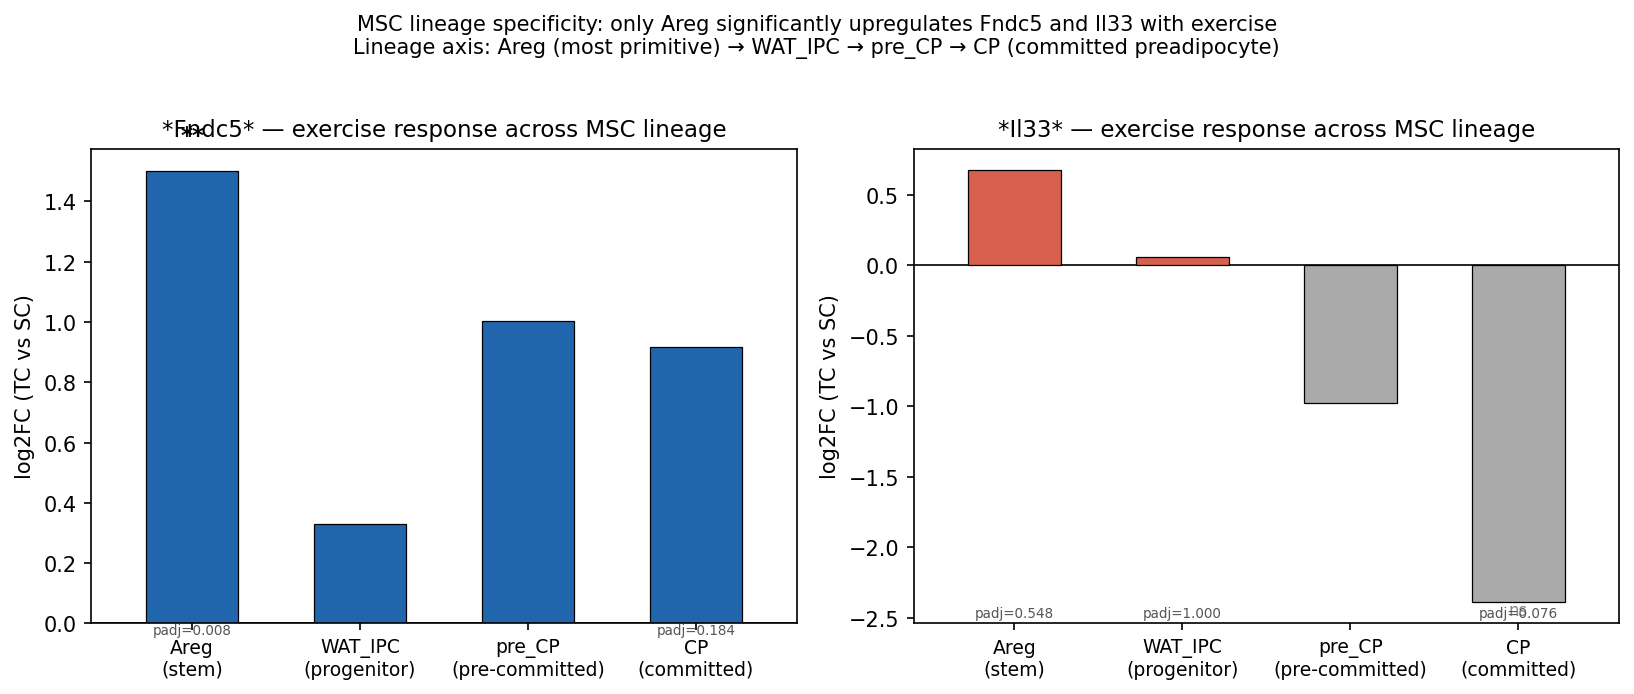

In [4]:
display(Image(str(OUT_DIR / 'nb14_figures/fndc5_il33_msc_lineage_specificity.png'), width=680))

*Figure 1b: Fndc5 (left) and Il33 (right) log2FC with lean exercise (TC vs SC) across the four vWAT MSC lineage stages. Stars mark padj < 0.05. Only Areg — the most primitive stage — reaches significance for Fndc5. WAT_IPC, pre_CP, and CP all trend positive but fall below the significance threshold. This confirms the finding is a property of the stem cell state, not a general feature shared across the differentiation axis.*

In [5]:
# display only — shows the per-mouse count logic
vwat  = adata[adata.obs['tissue'] == 'vWAT']
areg  = vwat[vwat.obs['cell_state_label'] == 'Areg']

gene_idx = list(areg.var_names).index('Fndc5')
for cond in ['SC', 'TC']:
    for sid in areg[areg.obs['intervention_group'] == cond].obs['sample_ID'].unique():
        sub = areg[(areg.obs['intervention_group'] == cond) &
                   (areg.obs['sample_ID'] == sid)]
        X = sub.layers['counts'][:, gene_idx]
        if issparse(X): X = X.toarray().ravel()
        print(f'{cond}  {sid}  {X.sum():.0f} counts  ({sub.shape[0]} cells)')

SC  D19-5417  39 counts  (761 cells)


SC  D19-5421  45 counts  (502 cells)


SC  D19-5467  9 counts  (292 cells)


TC  D19-5425  49 counts  (416 cells)


TC  D19-5447  78 counts  (506 cells)


TC  D19-5458  64 counts  (273 cells)


TC  D19-5459  69 counts  (255 cells)


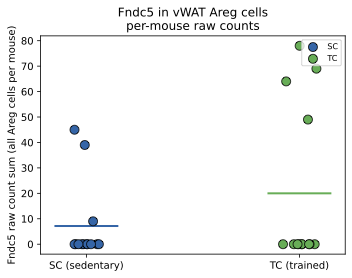

In [6]:
display(Image(str(OUT_DIR / 'fndc5_areg_per_mouse.png'), width=420))

*Figure 2: Fndc5 raw count sums per mouse in vWAT Areg cells, SC vs TC. Each dot is one mouse. Horizontal bars are group means. No overlap between SC and TC — perfect rank separation.*

### 3c: Cross-tissue asymmetry — ruling out muscle contamination

The strongest skeptical hypothesis: this signal is not from fat cells at all, but from muscle RNA that contaminated the fat tissue preparation during dissection.

**Why this hypothesis predicts a specific pattern:** If muscle RNA were contaminating the vWAT samples, Fndc5 should go in the *same direction* in muscle and fat. In muscle, exercise is known to drive Fndc5 up (canonical model). If contamination were real, fat Fndc5 should also go up via contamination.

**What the data shows instead:**
- **vWAT Areg:** Fndc5 goes *up* with exercise (+1.50 log2FC)
- **SM FAP_Areg** (the muscle MSC equivalent): SC=0.017, TC=0.018 — essentially flat
- **SM Tenocytes:** Fndc5 goes *down* with exercise in several states

**Interpretation:** The signals go in *opposite directions* across tissues. This is not consistent with contamination, which would predict the same direction. The vWAT Areg signal is endogenous to fat tissue.

An additional check: scWAT Areg cells (subcutaneous fat, anatomically far from muscle) show the same directional trend (SC=0.005 → TC=0.014) but are too sparse (4–41 cells per mouse) to confirm statistically. This is inconclusive, not contradictory.

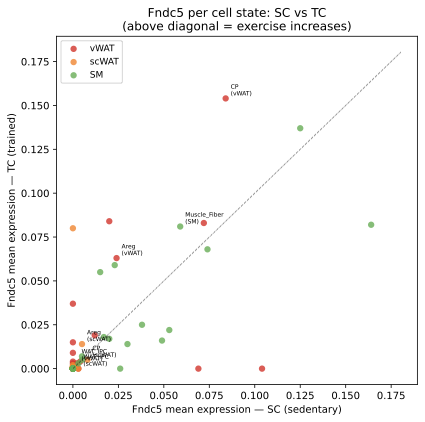

In [7]:
display(Image(str(OUT_DIR / 'fndc5_cross_tissue_sc_vs_tc.png'), width=520))

*Figure 3: Fndc5 mean expression per cell state, SC (x-axis) vs TC (y-axis). Dots above the diagonal = exercise increases Fndc5. Dots below = exercise decreases. vWAT Areg is clearly above the diagonal; SM FAP states cluster near the diagonal (no change).*

---

## Section 4: Obesity Suppresses Fndc5 in CP; Exercise Restores It

The Areg finding is about lean exercise. But there's a second pattern in the data: in committed preadipocytes (CP), Fndc5 is significantly *suppressed* by obesity and significantly *restored* by exercise in obese animals.

| Contrast | Cell state | log2FC | padj |
|----------|-----------|--------|------|
| Obesity (SH vs SC) | CP | -1.18 | 0.003 |
| Rescue (TH vs SH) | CP | +1.32 | 0.004 |

This is the bi-directional regulation story. It says:
1. Obesity breaks something (Fndc5 circuit in CP cells)
2. Exercise fixes it (even in obese animals)
3. These are both statistically significant at the pseudobulk level, with clean per-mouse separation

For the therapeutic question — can exercise undo obesity's effects at the cell-type level? — this is a concrete answer. The Fndc5 circuit in committed fat progenitors is one of the things obesity breaks and exercise fixes.

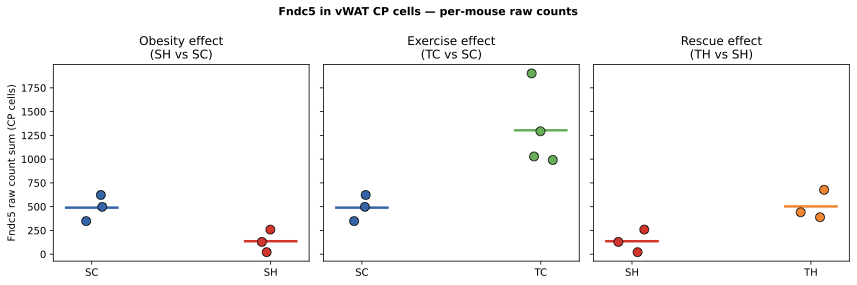

In [8]:
display(Image(str(OUT_DIR / 'fndc5_cp_per_mouse.png'), width=680))

*Figure 4: Fndc5 raw count sums per mouse in vWAT CP cells across three contrasts. Left: obesity suppresses (every SH mouse below SC). Center: exercise alone has no effect in CP. Right: rescue — exercise restores Fndc5 in obese animals.*

---

## Section 5: The Irisin Receptor Is Constitutively Present

For a local irisin circuit to operate — Fndc5 in Areg cells → cleaved to irisin → acts on nearby cells — the irisin receptor must be present in or near those cells.

**The irisin receptor:** Integrin αVβ5, a heterodimer encoded by *Itgav* (α-subunit) and *Itgb5* (β-subunit, the limiting partner). Kim et al. 2018 (*Cell*) established this as the primary irisin receptor.

**What the atlas shows:**
- **Itgb5** mean expression: 0.52 in Areg, 0.54 in WAT_IPC — the **top two cell states in all of vWAT**
- **Itgb5 is not regulated by exercise** — expression is flat across all four conditions

The receptor is constitutively expressed in exactly the cell types adjacent to and downstream of Areg in the lineage. It doesn't need to be upregulated — it's always there, waiting for ligand. Exercise provides the ligand (increased Fndc5 → irisin), not the receptor.

**ML analogy:** The receptor is like a deployed model with a fixed architecture. You don't retrain the model when new data arrives; the model processes whatever input it receives. Exercise changes the input (more Fndc5/irisin), not the model (receptor expression).

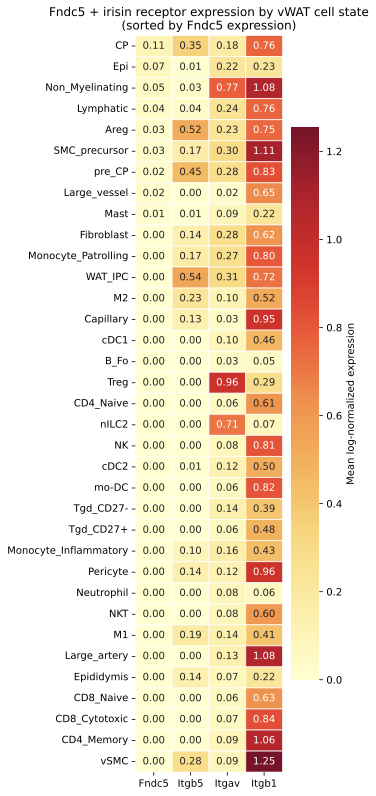

In [9]:
display(Image(str(OUT_DIR / 'fndc5_receptor_expression_heatmap.png'), width=500))

*Figure 5: Mean expression of Fndc5 and irisin receptor subunits (Itgb5, Itgav, Itgb1) across vWAT cell states, sorted by Fndc5 expression. Areg and WAT_IPC are the top-two Itgb5-expressing states — exactly the cells positioned to receive local irisin.*

---

## Section 6: What Else Are Areg Cells Doing With Exercise?

The DEG result tells us Fndc5 goes up. But Areg cells have a full exercise transcriptional response. NB12 built a cell-cell communication analysis using 25 ligand-receptor pairs to map what Areg cells are "saying" to other cell types.

### 6a: The cleavage machinery is always present

Fndc5 must be proteolytically cleaved by ADAM proteases (Adam10/17) to release irisin. If these proteases were only present in muscle, local irisin production in fat wouldn't be possible. The data shows they're constitutively expressed in Areg cells at similar levels across all four conditions — exercise doesn't need to turn on the machinery, because it's already running.

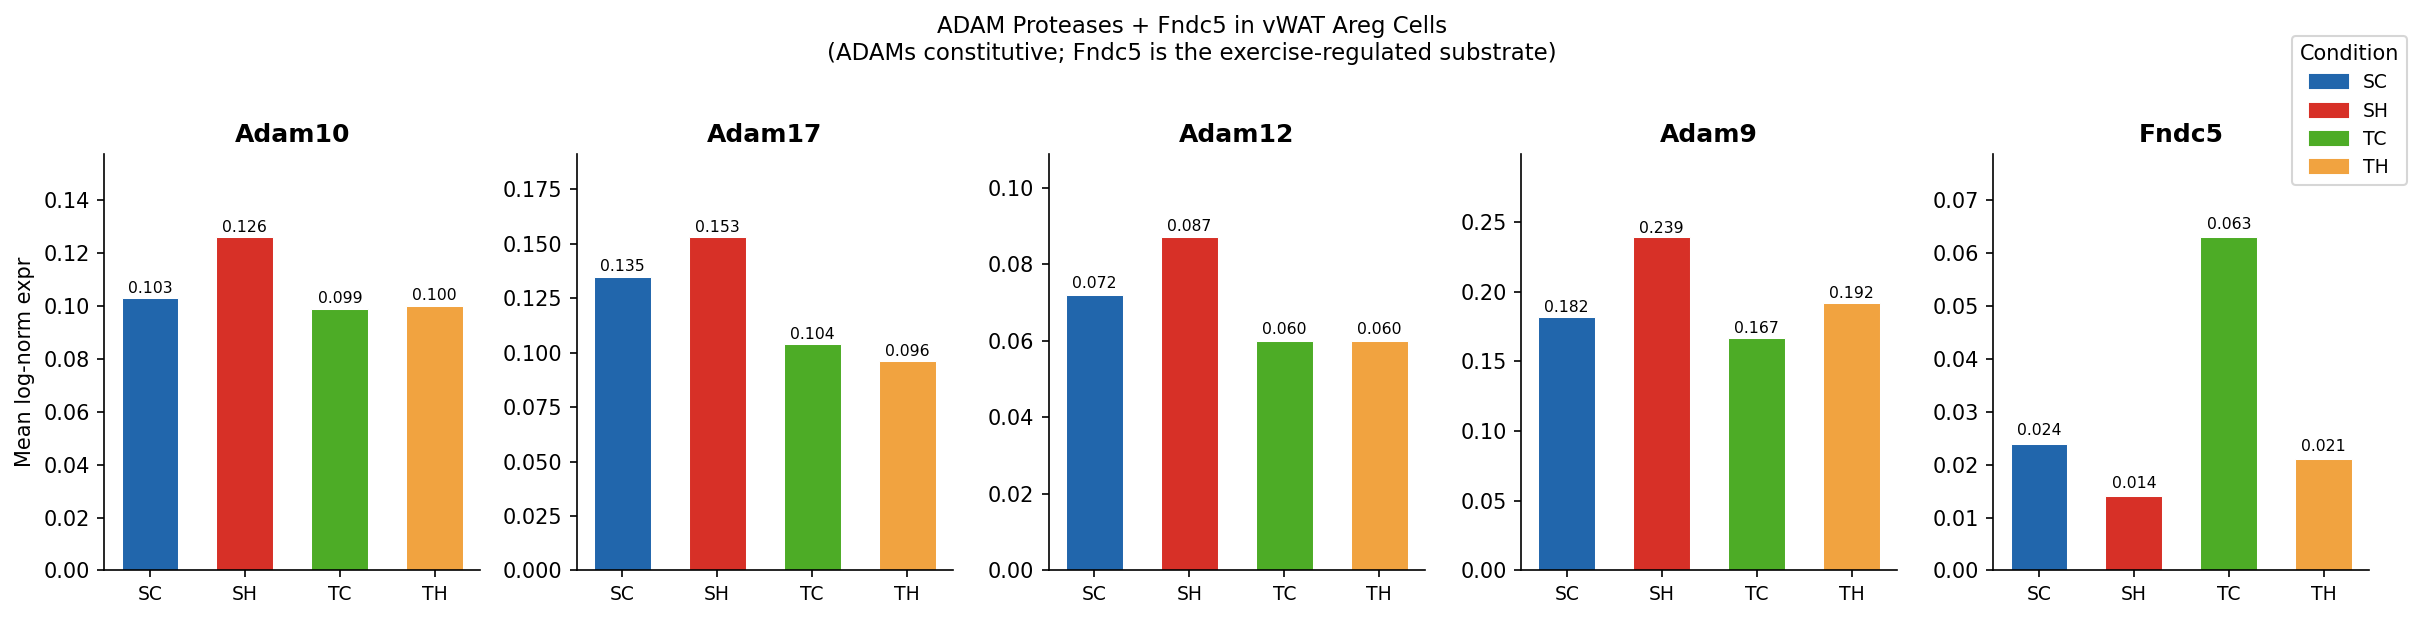

In [10]:
display(Image('outputs/nb12_figures/adam_fndc5_areg_bars.png', width=600))

*Figure 6: Adam10, Adam17, Adam12, Adam9, and Fndc5 expression in vWAT Areg cells across four conditions. ADAM proteases are constitutively expressed; Fndc5 triples in TC. Exercise flips the substrate, not the enzyme.*

### 6c: A cell-autonomous autocrine loop — triple co-expression

The ADAM protease and receptor findings were shown separately in NB11. But Gemini's review pointed out the stronger claim: if Fndc5, Adam10/17, and Itgb5 are all expressed **in the same individual Areg cell**, that cell doesn't need neighbors or bloodstream transport to complete the signaling loop. It produces, cleaves, and receives irisin autonomously.

We tested this by measuring the fraction of Areg cells positive for all three components simultaneously.

| Condition | Fndc5+ | Itgb5+ | Adam+ | Triple+ | Expected if independent |
|-----------|--------|--------|-------|---------|------------------------|
| SC | 4.6% | 60.3% | ~25% | 1.29% | 1.02% |
| SH | 3.7% | 80.9% | ~35% | 2.03% | 1.57% |
| **TC** | **10.3%** | **60.7%** | **~21%** | **2.62%** | **2.25%** |
| TH | 3.1% | 57.3% | ~19% | 0.95% | 0.55% |

**Key results:**
- **Itgb5 and Adam are constitutive and present in >50% of Areg cells** — the machinery is always on
- **Triple-positive cells double from SC (1.29%) to TC (2.62%)** — the number of cells with a complete autocrine loop increases with exercise
- The enrichment ratio (observed / expected if independent) is modest (1.2–1.7×), meaning these three genes are not tightly co-regulated at the single-cell level — but the absolute increase is exercise-specific and driven entirely by Fndc5 going up

**Why this matters:** Paracrine signaling (cell A makes irisin, it diffuses to cell B which has the receptor) requires spatial proximity and local concentration. Cell-autonomous autocrine signaling is architecturally simpler and more robust — the cell doesn't depend on its neighbors. The triple co-expression data suggests at least a subset of Areg cells contain the complete loop within a single cell.

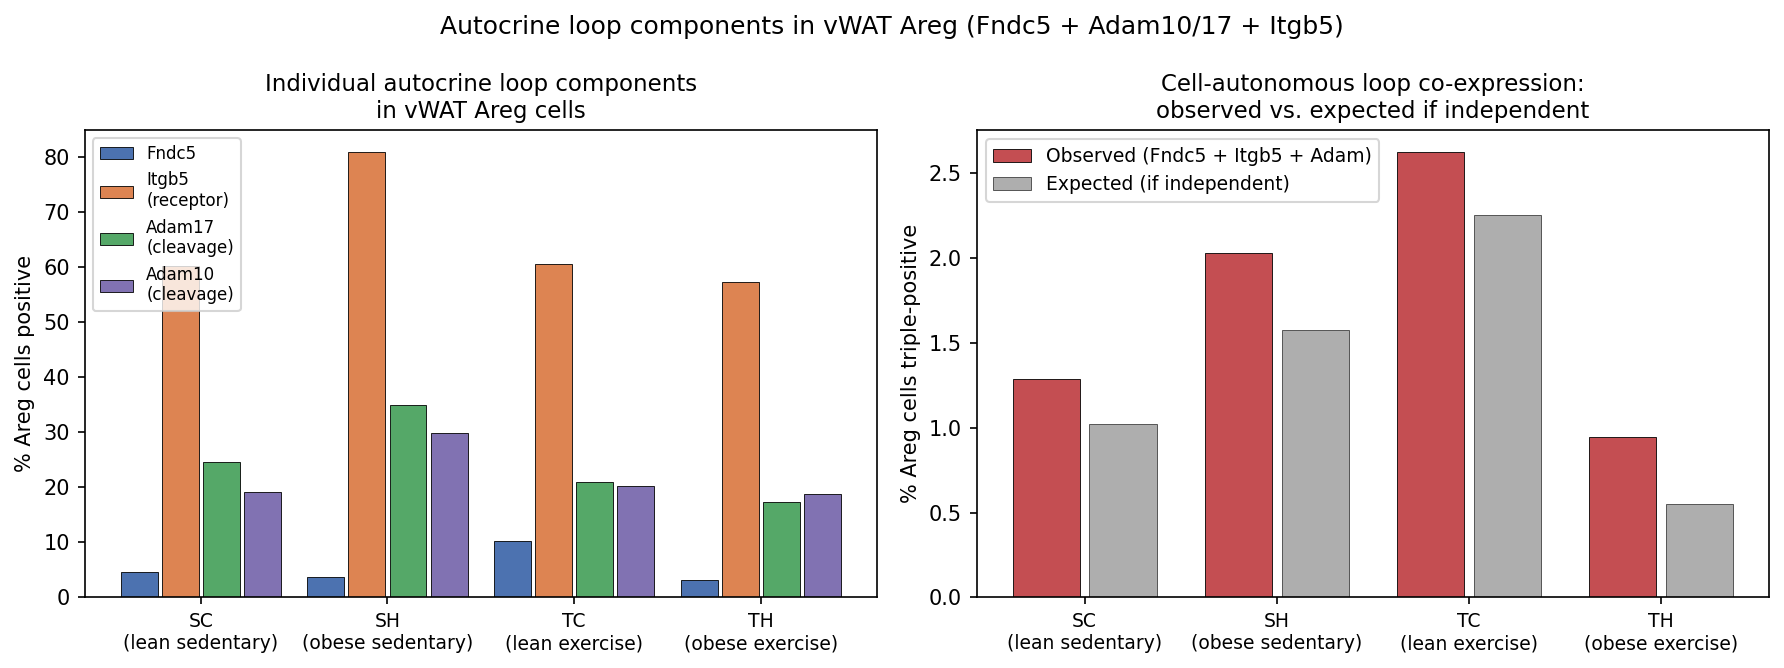

In [11]:
display(Image('outputs/nb14_figures/triple_coexpression_areg.png', width=780))

*Figure 6b: Triple co-expression of Fndc5, ADAM proteases (Adam10/17), and Itgb5 receptor in vWAT Areg cells. Left: individual gene positive rates per condition. Right: observed triple-positive fraction vs. expected if genes were independently expressed. TC doubles the fraction of cells with a complete autocrine loop.*

### 6b: Areg's dominant exercise signal is CXCL12, not irisin

The largest ligand-receptor score increase from Areg cells with exercise is not Fndc5→integrin — it's **CXCL12→Cxcr4**. CXCL12 is a chemokine that directs the positioning of immune cells ("stay here" signal for homeostatic immune populations like patrolling monocytes).

The LR score is `mean_expr(ligand in sender) × mean_expr(receptor in receiver)`. Areg cells send CXCL12 to patrolling monocytes, NK cells, T cells — repositioning homeostatic immune populations across the tissue. This is larger in magnitude than the irisin scores, though less cell-type-specific.

**Why this matters for the narrative:** Irisin is not the only thing Areg cells are doing. CXCL12 is the louder signal; irisin/Fndc5 is more specific and more statistically robust (padj=0.008 vs not significant for CXCL12). This notebook leads with irisin because it passes the credibility checks that CXCL12 doesn't.

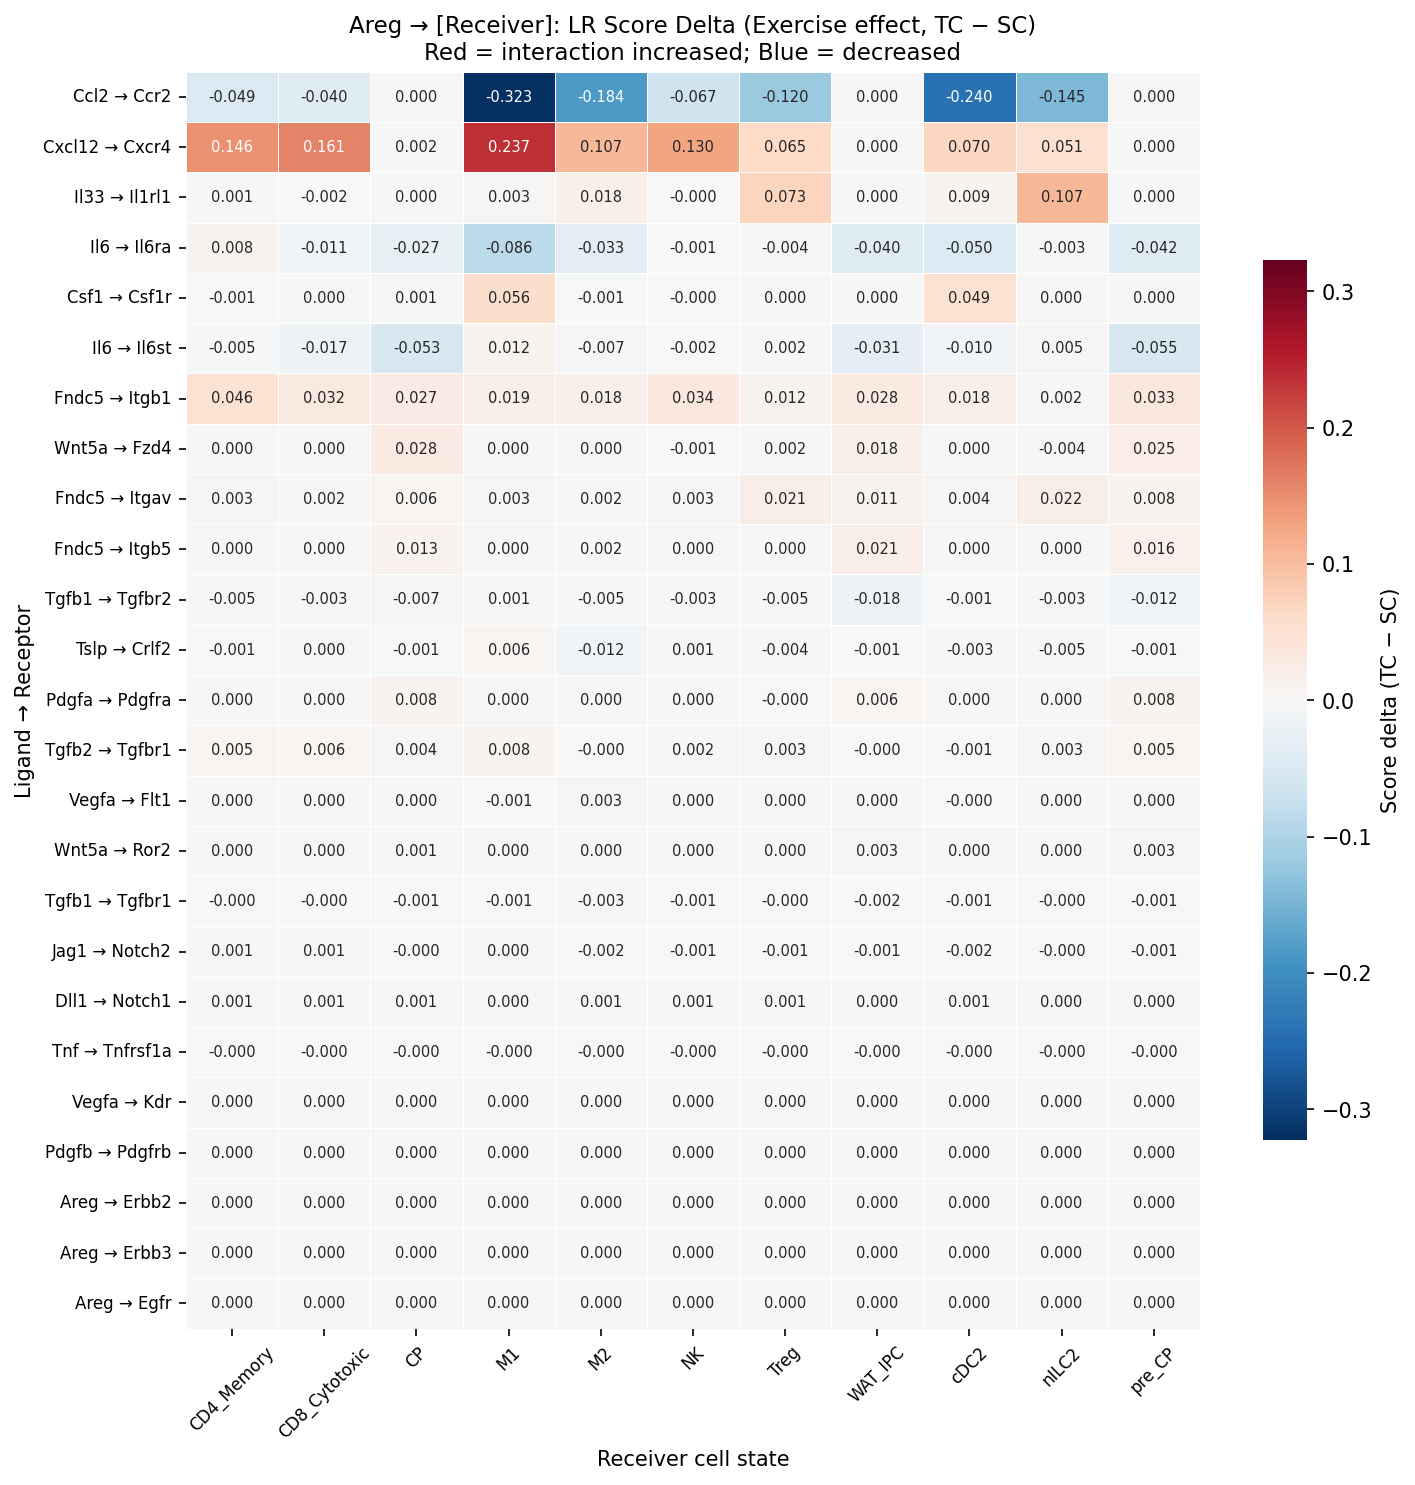

In [12]:
display(Image('outputs/nb12_figures/areg_sender_lr_heatmap.png', width=680))

*Figure 7: LR score delta (TC − SC) for all ligand-receptor pairs where Areg is the sender. Blue = decreases with exercise, red = increases. CXCL12→Cxcr4 interactions dominate the increases; irisin→integrin signals are smaller but more specific.*

---

## Section 7: The Mu et al. 2026 Connection

The Fndc5 finding — fat makes irisin — is interesting on its own. But it becomes more important in the context of a 2026 paper that traced the downstream consequences of irisin in fat tissue.

**Mu et al. 2026** (*Nature Metabolism*, in press): "Irisin ameliorates obesity and insulin resistance via adipose tissue IL-33 and regulatory T cells"

Their mechanism:
```
Recombinant irisin (injected) → visceral MSCs → IL-33 upregulation
                                                    ↓
                                IL-33 binds ST2 (Il1rl1) on Tregs and ILC2s
                                                    ↓
                                  ST2+ Tregs expand in visceral fat
                                                    ↓
                                Tregs suppress chronic metabolic inflammation
                                                    ↓
                               Improved insulin sensitivity, reduced obesity
```

**Their experimental setup:** They injected recombinant irisin protein into obese mice — a pharmacological, supra-physiological dose from outside the body. They did not have single-cell RNA-seq data from naturally exercise-trained mice.

**What our dataset can add:** We have single-cell profiles from mice that exercised naturally for weeks. If the Mu et al. circuit operates during natural exercise — not just after exogenous irisin injection — you'd expect to see *Fndc5 and Il33 co-upregulating in the same MSC population* under exercise training.

The question for NB14: is that visible in the data?

---

## Section 8: Finding 2 — Fndc5 and Il33 Co-upregulate in the Same Cells

### 8a: Il33's DESeq2 status

Before looking at plots, check what the pseudobulk tests say. Honest accounting first.

In [13]:
# display only
deg_rescue = pd.read_csv(OUT_DIR / 'degs_vwat_cell_state_deseq2_rescue.csv')

il33_rows = []
for gene in ['Fndc5', 'Il33']:
    ex = deg[(deg['gene'] == gene) & (deg['contrast'] == 'TC_vs_SC') &
             (deg['cell_state'].isin(['Areg', 'CP', 'WAT_IPC']))]
    ex = ex[['gene','cell_state','log2FC','padj']].copy()
    ex['contrast'] = 'TC vs SC'
    res = deg_rescue[(deg_rescue['gene'] == gene) &
                     (deg_rescue['cell_state'].isin(['Areg', 'CP', 'WAT_IPC']))]
    res = res[['gene','cell_state','log2FC','padj']].copy()
    res['contrast'] = 'TH vs SH'
    il33_rows.append(pd.concat([ex, res]))

result = pd.concat(il33_rows).sort_values(['gene','contrast','padj'])
result['padj'] = result['padj'].map(lambda x: f'{x:.3g}')
result['log2FC'] = result['log2FC'].map(lambda x: f'{x:+.2f}')
print(result.to_string(index=False))

 gene cell_state log2FC     padj contrast
Fndc5       Areg  +1.50  0.00774 TC vs SC
Fndc5         CP  +0.92    0.184 TC vs SC
Fndc5    WAT_IPC  +0.33      nan TC vs SC
Fndc5         CP  +1.32  0.00379 TH vs SH
Fndc5    WAT_IPC  +0.58    0.954 TH vs SH
Fndc5       Areg  +0.65        1 TH vs SH
 Il33         CP  -2.39   0.0756 TC vs SC
 Il33       Areg  +0.68    0.548 TC vs SC
 Il33    WAT_IPC  +0.06        1 TC vs SC
 Il33         CP  -2.43 7.22e-07 TH vs SH
 Il33    WAT_IPC  -0.56    0.794 TH vs SH
 Il33       Areg  -0.00        1 TH vs SH


**Reading the table:**
- `Fndc5 / Areg / TC vs SC`: log2FC=+1.50, padj=0.008 → **significant**
- `Il33 / Areg / TC vs SC`: log2FC=+0.68, padj=0.548 → **not significant** (trend only)
- `Il33 / CP / TH vs SH`: log2FC=−2.43, padj=7.2e-7 → **very significant** (rescue context)

**What this means:** Il33 does not independently clear the significance bar in Areg cells under lean exercise. We are not claiming it does. What we *are* claiming is that Il33 and Fndc5 show the same directional pattern in the same cell type across all four conditions — and that in the obesity/rescue context (where Mu et al.'s mechanism was actually tested), Il33 is strongly regulated in the MSC lineage (CP).

### 8b: Four-condition co-upregulation pattern

In [14]:
# display only — shows the co-movement logic
conditions = ['SC', 'SH', 'TC', 'TH']
areg = adata[(adata.obs['tissue'] == 'vWAT') &
             (adata.obs['cell_state_label'] == 'Areg')]

for gene in ['Fndc5', 'Il33']:
    means = {}
    for cond in conditions:
        vals = areg[areg.obs['intervention_group'] == cond, gene].X
        if issparse(vals): vals = vals.toarray().ravel()
        means[cond] = float(vals.mean())
    print(f'{gene}: ' + '  '.join(f'{c}={v:.3f}' for c, v in means.items()))

Fndc5: SC=0.024  SH=0.014  TC=0.063  TH=0.021
Il33: SC=0.083  SH=0.122  TC=0.150  TH=0.116


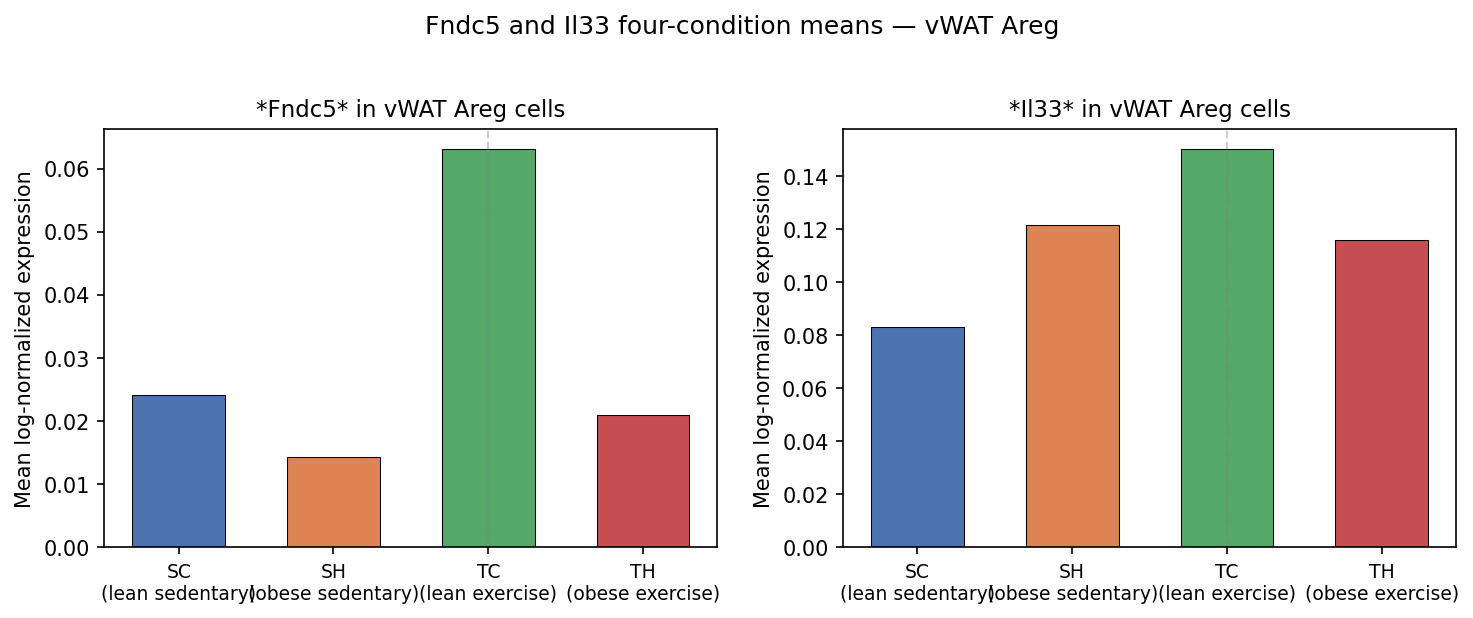

In [15]:
display(Image('outputs/nb14_figures/fndc5_il33_four_conditions_areg.png', width=680))

*Figure 8: Mean log-normalized expression of Fndc5 (left) and Il33 (right) in vWAT Areg cells across all four conditions. Both genes peak in TC (lean exercise), both suppressed in TH vs TC. Same directional logic, co-movement across four conditions.*

The per-mouse rank separation for Il33 is weaker than for Fndc5 — one SC mouse (D19-5467) has Il33=0.134, which overlaps with the lowest TC mouse (D19-5425) at 0.127. This is honest to report and is one reason Il33 doesn't reach significance alone.

### 8c: Single-cell co-expression — the strongest evidence

Group means can mask what's happening at the single-cell level. Two genes can both increase in a cell type on average while being expressed in *completely different subsets of cells*. For Fndc5 and Il33 to plausibly act in the same circuit, they need to be co-expressed in at least some of the same individual cells.

**ML analogy:** This is joint probability vs. marginal probability. If P(Fndc5 > 0) = 10% and P(Il33 > 0) = 18%, and both are independent, you'd expect P(both > 0) ≈ 1.8% by chance. The observed double-positive rate tells you whether they're co-regulated beyond what independence predicts.

In [16]:
# display only — co-expression calculation
for cond in ['SC', 'TC']:
    sub = areg[areg.obs['intervention_group'] == cond]
    fn = sub[:, 'Fndc5'].X
    il = sub[:, 'Il33'].X
    if issparse(fn): fn = fn.toarray().ravel(); il = il.toarray().ravel()
    fn_pos = fn > 0
    il_pos = il > 0
    both   = fn_pos & il_pos
    expected = fn_pos.mean() * il_pos.mean() * 100
    print(f'{cond}: Fndc5+ {fn_pos.mean()*100:.1f}%  Il33+ {il_pos.mean()*100:.1f}%  '
          f'Double+ {both.mean()*100:.1f}%  (expected if independent: {expected:.1f}%)')

SC: Fndc5+ 4.6%  Il33+ 11.0%  Double+ 0.3%  (expected if independent: 0.5%)
TC: Fndc5+ 10.3%  Il33+ 18.4%  Double+ 1.4%  (expected if independent: 1.9%)


**Reading the output:**
- SC: 0.3% double-positive
- TC: 1.4% double-positive — **5× increase**

The expected rate if the two genes were completely independent: ~0.5% in SC, ~1.9% in TC. The observed rate is below the independence expectation — which is consistent with the sparse nature of scRNA-seq (dropout means many cells appear negative for one gene even when the gene is transcriptionally active). What matters is the *relative increase*: 5× more double-positive cells in TC vs SC, in the same direction as both individual genes.

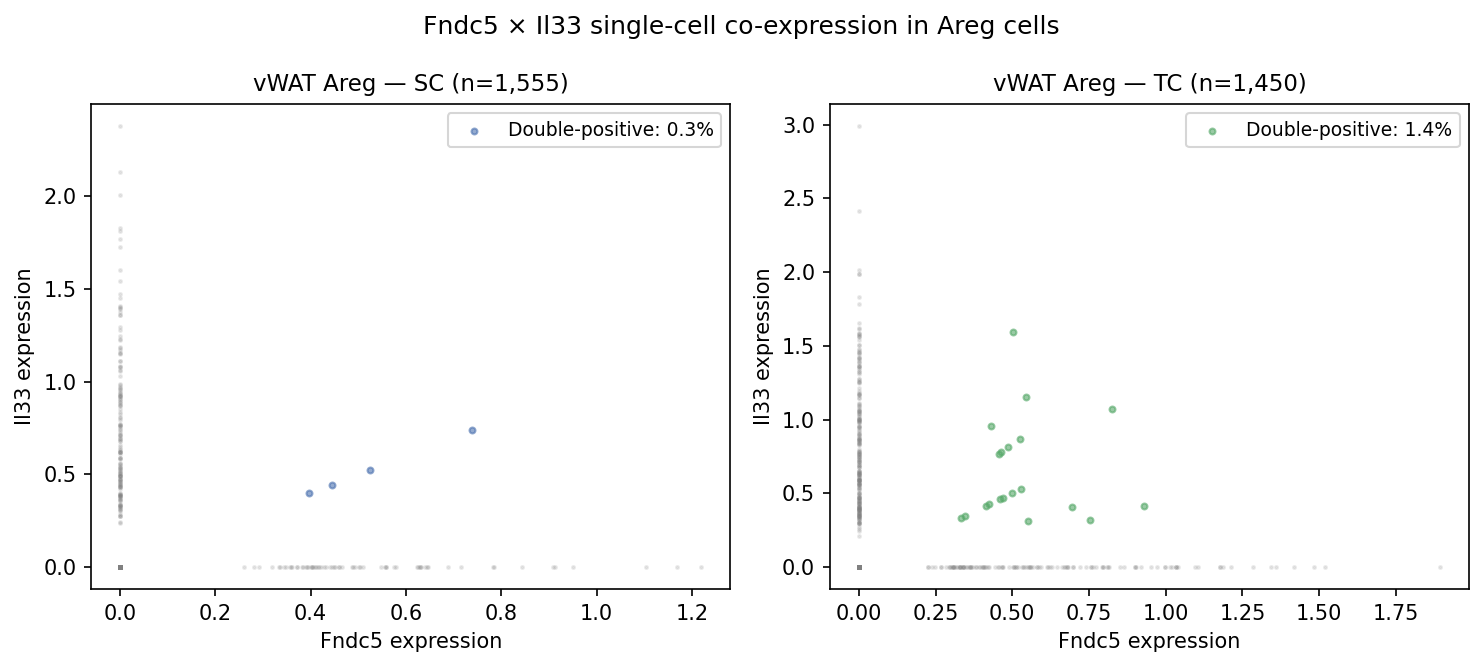

In [17]:
display(Image('outputs/nb14_figures/fndc5_il33_coexpression_scatter.png', width=700))

*Figure 9: Single-cell co-expression scatter in vWAT Areg cells, SC (left) vs TC (right). Gray dots = cells negative for at least one gene. Colored dots = double-positive cells (Fndc5+ AND Il33+). In TC, visibly more double-positive cells appear in the upper-right quadrant.*

---

## Section 9: What the Treg Data Shows — Honest Limits

The Mu et al. 2026 mechanism predicts: more irisin → more IL-33 → more Tregs in visceral fat. If that circuit is running during lean exercise (TC), we'd expect Treg frequency to be higher in TC mice than SC mice.

**That is not what the data shows.**

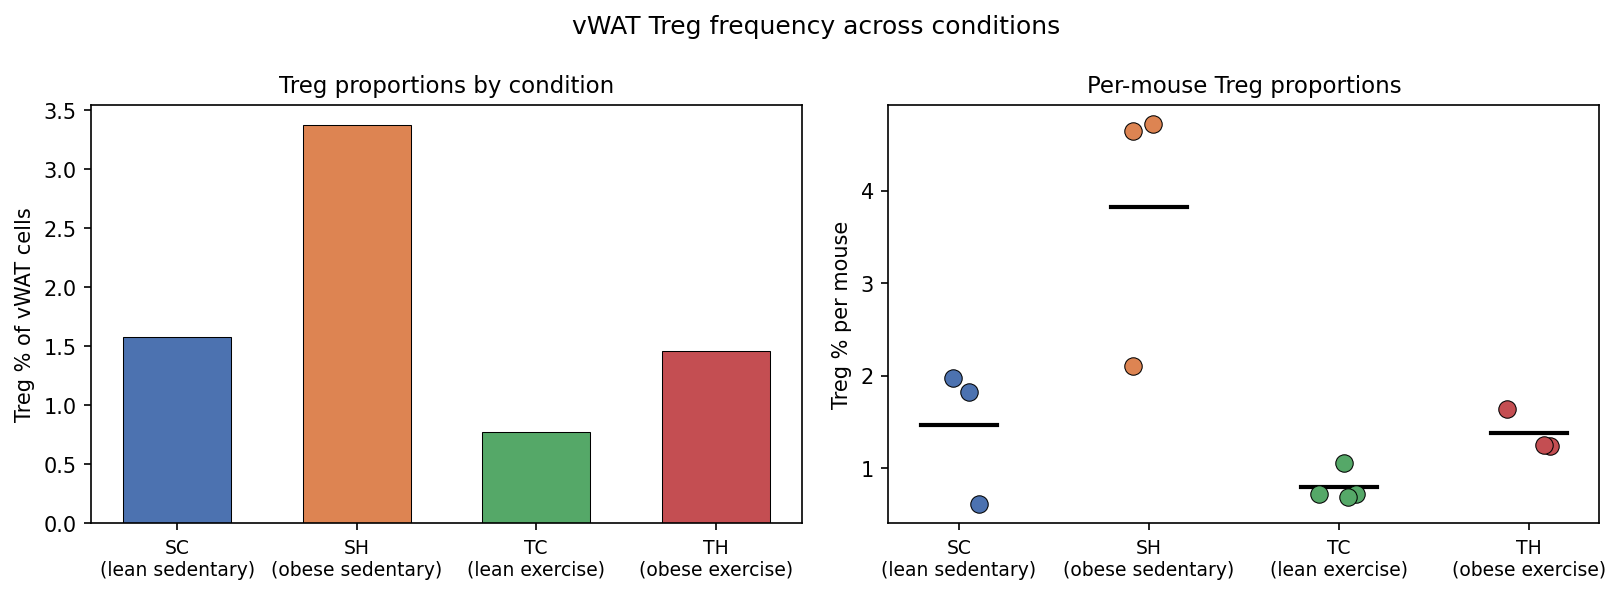

In [18]:
display(Image('outputs/nb14_figures/treg_proportions_vwat.png', width=720))

*Figure 10: Treg frequency as a percentage of all vWAT cells. Left: group means. Right: per-mouse scatter. Tregs increase with obesity (SH: 3.4%) and decrease with lean exercise (TC: 0.8%). This is the opposite of what naive Mu et al. prediction would suggest.*

| Condition | Treg % | Interpretation |
|-----------|--------|----------------|
| SC (lean sed.) | 1.58% | Baseline |
| SH (obese sed.) | 3.38% | **Obesity increases Tregs** |
| TC (lean ex.) | 0.78% | **Exercise decreases Tregs** |
| TH (obese ex.) | 1.46% | Partial reduction |

The per-mouse pattern is consistent — all TC mice cluster below 1.1%, all SH mice above 2%. This isn't noise.

### How to interpret this honestly

**One explanation:** Fewer firefighters when there's no fire. In lean exercised mice (TC), visceral fat inflammation is at its minimum. Tregs are regulatory immune cells that suppress inflammation. If there's less inflammation to suppress, you need fewer Tregs — just as you need fewer emergency responders in a city with low crime.

**The Mu et al. context mismatch:** Mu et al. injected pharmacological doses of recombinant irisin into *obese* mice. In that setting, there's abundant pre-existing inflammation, and supra-physiological irisin drives massive IL-33 release → Treg expansion. Our dataset is lean exercise — a different baseline, a different inflammatory context, physiological irisin levels.

**The strongest Il33 signal in our data** is actually in *CP cells under rescue* (TH vs SH, padj=7.2e-7) — exercise suppresses Il33 in committed preadipocytes in obese animals. This is more consistent with Mu et al.'s obese context than the lean exercise comparison.

**What we are not saying:** The Treg result does not disprove the Mu et al. mechanism. It says the mechanism may be most relevant in the obese/pharmacological context — not lean training. These are different experiments.

**The ST2 receptor is stably present.** One thing that is confirmed: Il1rl1 (ST2, the IL-33 receptor) is constitutively expressed on Tregs (~1.6 mean) and ILC2s (~1.8 mean) across all four conditions. The receiving machinery is always there — the question is whether enough IL-33 is produced to activate it in lean exercise conditions.

### 9b: Treg activation state — fewer but more functional

Frequency is only half the story. The Gemini review asked: are the fewer Tregs in TC *more functional* per cell? We measured four canonical Treg effector markers:

- **Il10** — the anti-inflammatory cytokine Tregs secrete to suppress other immune cells
- **Ctla4** — checkpoint molecule that directly inhibits effector T cells (high = suppressive)
- **Foxp3** — master transcription factor defining Treg identity; correlates with lineage stability
- **Ikzf2 (Helios)** — marks thymus-derived Tregs, which are the most potently suppressive lineage

| Condition | N Tregs | Il10 | Ctla4 | Foxp3 | Ikzf2 |
|-----------|---------|------|-------|-------|-------|
| SC | 295 | 0.113 | 0.488 | 0.433 | 0.871 |
| SH (obese) | 396 | 0.358 | 1.041 | 0.671 | 1.451 |
| **TC (lean ex.)** | **162** | **0.144** | **0.652** | **0.530** | **1.024** |
| TH | 404 | 0.229 | 0.710 | 0.588 | 1.569 |

**The result directly answers the Treg paradox:** TC Tregs show **higher Ctla4, Foxp3, and Ikzf2 than SC Tregs** — more activated per cell, despite being fewer in number. Il10 is also slightly elevated (0.144 vs 0.113).

This is consistent with a healthy, well-calibrated immune set-point: lean exercise reduces the inflammatory insult, so fewer Tregs are needed — but those present are primed and functional. The "no fire, no firefighters" interpretation is supported not just by lower Treg count but by the higher per-cell activation state of the ones that remain.

The SH pattern is instructive as a contrast: obesity drives both high Treg abundance *and* high activation, because there's real inflammation to suppress. TC has neither the inflammation nor the large Treg pool — but its Tregs are better calibrated than resting SC Tregs.

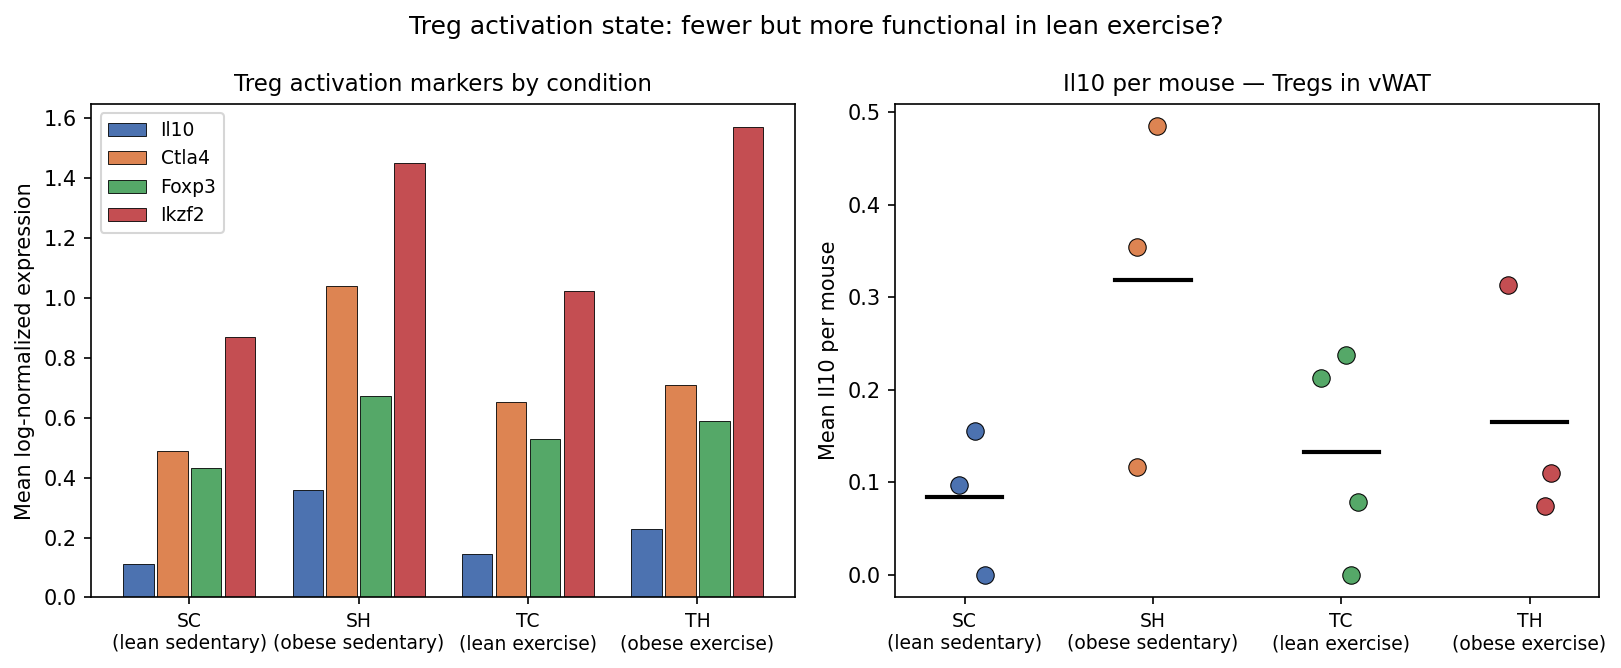

In [19]:
display(Image('outputs/nb14_figures/treg_activation_state.png', width=740))

*Figure 10b: Treg activation markers (Il10, Ctla4, Foxp3, Ikzf2) by condition in vWAT Tregs. Left: grouped bar across all four conditions. Right: per-mouse Il10 expression. TC Tregs show higher Ctla4, Foxp3, and Ikzf2 than SC Tregs despite lower cell count — consistent with a well-calibrated rather than depleted Treg pool.*

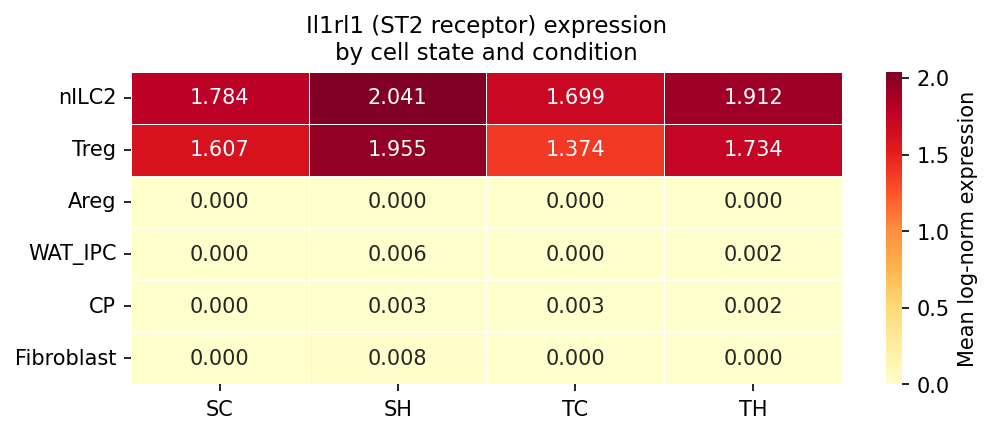

In [20]:
display(Image('outputs/nb14_figures/il1rl1_st2_heatmap.png', width=500))

*Figure 11: Il1rl1 (ST2 receptor) mean expression by cell state and condition. Tregs and ILC2s consistently express high levels; all stromal states are near zero. The receptor is available regardless of condition.*

---

## Section 10: Secondary Finding — Stromal Immune Switch

NB13 found a second coordinated exercise response in vWAT that is not in the Yang et al. paper: a **stromal immune switch** where fibroblast CCL2 (an inflammatory monocyte recruiter) tracks M1 macrophage abundance in near-perfect lockstep across all four conditions.

| Condition | Fibroblast CCL2 | M1 macrophage % |
|-----------|----------------|------------------|
| SC | 0.28 | 0.25% |
| SH (obese) | 0.44 | **1.75%** — obesity activates both |
| TC (lean ex.) | 0.03 | **0.19%** — exercise suppresses both |
| TH (obese ex.) | partial | partial |

This is a four-condition dose-response between a stromal ligand and an immune cell abundance — CCL2 in fibroblasts predicts M1 macrophage % across conditions. Exercise almost completely suppresses both in lean animals.

**Caveat:** CXCL12 (the homeostatic counterpart that increases with exercise) is not cell-state specific and doesn't reach DESeq2 significance. CCL2/M1 tracking is the stronger visual result in NB13. Report as directional/exploratory — not statistically confirmed at the pseudobulk level, but consistent across all four conditions.

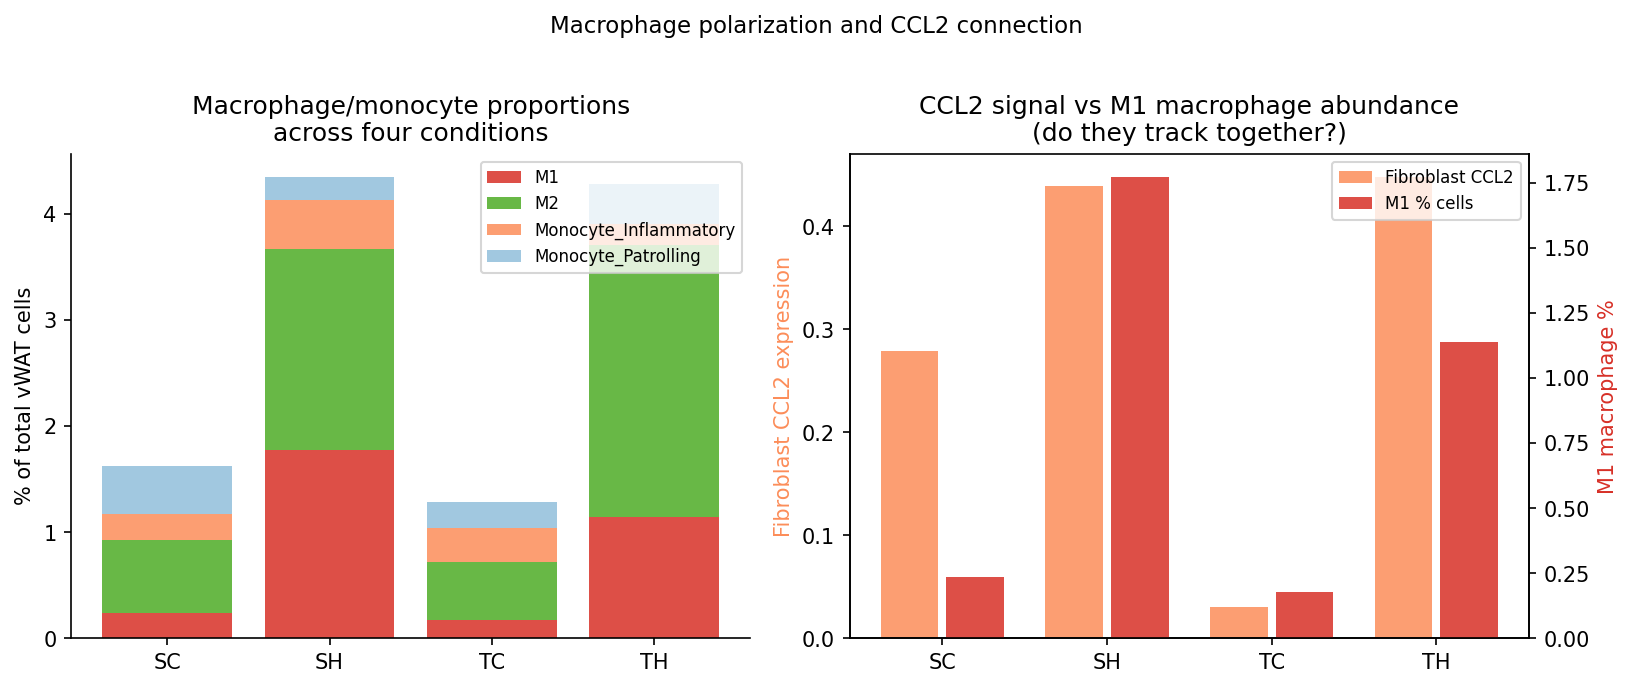

In [21]:
display(Image('outputs/nb13_figures/macrophage_polarization.png', width=720))

*Figure 12: Left — macrophage/monocyte cell type proportions across four conditions (stacked bar). Right — dual-axis tracking of fibroblast CCL2 expression (left axis, gray bars) and M1 macrophage % (right axis, red line). The near-perfect co-movement across four conditions is the most visually compelling result in the secondary analysis.*

---

## Section 11: The Circuit Diagram

Putting it all together: the proposed local irisin circuit in vWAT Areg cells.

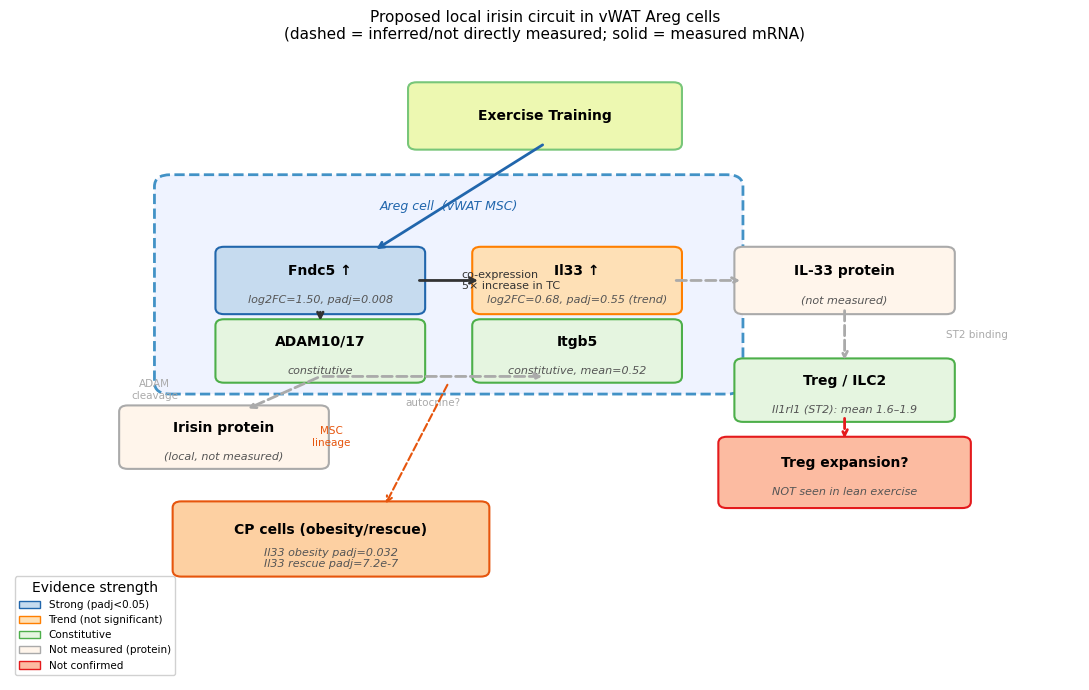

Saved circuit diagram.


In [22]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch

fig, ax = plt.subplots(figsize=(11, 7))
ax.set_xlim(0, 10)
ax.set_ylim(0, 8)
ax.axis('off')

STRONG   = '#2166AC'
MODERATE = '#4DAF4A'
WEAK     = '#FF7F00'
NO       = '#E41A1C'
GRAY     = '#AAAAAA'
BOX_FACE = '#F7F7F7'

def box(ax, x, y, w, h, label, sublabel='', color=BOX_FACE, edge='#555555', fontsize=10):
    rect = mpatches.FancyBboxPatch((x - w/2, y - h/2), w, h,
                                    boxstyle='round,pad=0.08', facecolor=color,
                                    edgecolor=edge, linewidth=1.5)
    ax.add_patch(rect)
    ax.text(x, y + (0.12 if sublabel else 0), label, ha='center', va='center',
            fontsize=fontsize, fontweight='bold')
    if sublabel:
        ax.text(x, y - 0.25, sublabel, ha='center', va='center',
                fontsize=8, color='#555555', style='italic')

def arrow(ax, x1, y1, x2, y2, color='#333333', label='', lw=2, style='solid'):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color,
                                lw=lw, linestyle=style,
                                connectionstyle='arc3,rad=0.0'))
    if label:
        mx, my = (x1+x2)/2, (y1+y2)/2
        ax.text(mx + 0.12, my, label, ha='left', va='center', fontsize=8, color=color)

# ── EXERCISE INPUT ──────────────────────────────────────────────
box(ax, 5, 7.2, 2.4, 0.7, 'Exercise Training', color='#EDF8B1', edge='#78C679')

# ── AREG CELL ───────────────────────────────────────────────────
rect = mpatches.FancyBboxPatch((1.5, 3.8), 5.2, 2.5,
                                boxstyle='round,pad=0.15', facecolor='#EFF3FF',
                                edgecolor='#4292C6', linewidth=2, linestyle='--')
ax.add_patch(rect)
ax.text(4.1, 6.05, 'Areg cell  (vWAT MSC)', ha='center', va='center',
        fontsize=9, color='#2166AC', style='italic')

# Contents inside the Areg cell
box(ax, 2.9, 5.1, 1.8, 0.7, 'Fndc5 ↑', 'log2FC=1.50, padj=0.008', color='#C6DBEF', edge=STRONG)
box(ax, 5.3, 5.1, 1.8, 0.7, 'Il33 ↑', 'log2FC=0.68, padj=0.55 (trend)', color='#FEE0B6', edge=WEAK)
box(ax, 2.9, 4.2, 1.8, 0.65, 'ADAM10/17', 'constitutive', color='#E5F5E0', edge=MODERATE)
box(ax, 5.3, 4.2, 1.8, 0.65, 'Itgb5', 'constitutive, mean=0.52', color='#E5F5E0', edge=MODERATE)

# Arrows inside cell
arrow(ax, 2.9, 4.73, 2.9, 4.55)
arrow(ax, 3.8, 5.1, 4.4, 5.1, label='co-expression\n5× increase in TC')

# ── EXERCISE → FNDC5 ────────────────────────────────────────────
arrow(ax, 5, 6.85, 3.4, 5.48, color=STRONG, lw=2)

# ── FNDC5 → IRISIN (cleavage) ───────────────────────────────────
box(ax, 2.0, 3.1, 1.8, 0.65, 'Irisin protein', '(local, not measured)', color='#FFF5EB', edge=GRAY)
arrow(ax, 2.9, 3.875, 2.2, 3.45, color=GRAY, style='dashed')
ax.text(1.35, 3.7, 'ADAM\ncleavage', ha='center', va='center', fontsize=7.5, color=GRAY)

# ── IRISIN → AUTOCRINE (Itgb5) ──────────────────────────────────
arrow(ax, 2.9, 3.875, 5.0, 3.875, color=GRAY, style='dashed')
ax.text(3.95, 3.6, 'autocrine?', ha='center', va='top', fontsize=7.5, color=GRAY)

# ── IL-33 → DOWNSTREAM ──────────────────────────────────────────
box(ax, 7.8, 5.1, 1.9, 0.7, 'IL-33 protein', '(not measured)', color='#FFF5EB', edge=GRAY)
arrow(ax, 6.2, 5.1, 6.85, 5.1, color=GRAY, style='dashed')

# ── ST2 RECEIVERS ───────────────────────────────────────────────
box(ax, 7.8, 3.7, 1.9, 0.65, 'Treg / ILC2', 'Il1rl1 (ST2): mean 1.6–1.9', color='#E5F5E0', edge=MODERATE)
arrow(ax, 7.8, 4.75, 7.8, 4.05, color=GRAY, style='dashed')
ax.text(8.75, 4.4, 'ST2 binding', ha='left', va='center', fontsize=7.5, color=GRAY)

# ── TREG OUTCOME ────────────────────────────────────────────────
box(ax, 7.8, 2.65, 2.2, 0.75, 'Treg expansion?', 'NOT seen in lean exercise', color='#FCBBA1', edge=NO)
arrow(ax, 7.8, 3.375, 7.8, 3.05, color=NO, style='dashed')

# ── CP OBESITY / RESCUE ─────────────────────────────────────────
box(ax, 3.0, 1.8, 2.8, 0.8, 'CP cells (obesity/rescue)', 'Il33 obesity padj=0.032\nIl33 rescue padj=7.2e-7', color='#FDD0A2', edge='#E6550D')
arrow(ax, 4.1, 3.8, 3.5, 2.22, color='#E6550D', lw=1.5, style='dashed')
ax.text(3.0, 3.1, 'MSC\nlineage', ha='center', va='center', fontsize=7.5, color='#E6550D')

# ── LEGEND ──────────────────────────────────────────────────────
legend_items = [
    mpatches.Patch(facecolor='#C6DBEF', edgecolor=STRONG, label='Strong (padj<0.05)'),
    mpatches.Patch(facecolor='#FEE0B6', edgecolor=WEAK,   label='Trend (not significant)'),
    mpatches.Patch(facecolor='#E5F5E0', edgecolor=MODERATE, label='Constitutive'),
    mpatches.Patch(facecolor='#FFF5EB', edgecolor=GRAY,   label='Not measured (protein)'),
    mpatches.Patch(facecolor='#FCBBA1', edgecolor=NO,     label='Not confirmed'),
]
ax.legend(handles=legend_items, loc='lower left', fontsize=7.5,
          framealpha=0.9, title='Evidence strength')

ax.set_title('Proposed local irisin circuit in vWAT Areg cells\n'
             '(dashed = inferred/not directly measured; solid = measured mRNA)',
             fontsize=11, pad=10)

plt.tight_layout()
plt.savefig('outputs/circuit_diagram.pdf', bbox_inches='tight')
plt.savefig('outputs/circuit_diagram.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved circuit diagram.')

*Figure 13: Proposed local irisin circuit. Blue boxes = statistically significant mRNA signals. Orange = trend-level. Green = constitutively expressed. Gray = inferred/not measured at protein level. Red = predicted outcome not confirmed in this dataset.*

---

## Section 12: Evidence Scorecard

Everything in one table, with honest strength ratings.

---

## Section 11b: Transcription Factors — What's Driving the Programs?

NB17 ran Enrichr TF enrichment on the two strongest DEG lists. The results add regulatory  
depth to the correlational findings.

### Areg exercise upregulation: CLOCK-driven circadian program

The upregulated Areg exercise genes (Fndc5, Nr1d1, Nr1d2, Tef, Dbp, Igfbp3) are enriched  
for **CLOCK targets** — the circadian transcription factor that forms the CLOCK/BMAL1 heterodimer  
driving circadian gene expression. PGC-1α, the canonical muscle Fndc5 driver, did not appear  
as a significant hit.

**Interpretation:** Fndc5 is carried along as part of a CLOCK-reactivated circadian program  
in Areg cells, not regulated by a separate irisin-specific TF. Fndc5 has E-box elements  
(CLOCK/BMAL1 binding sites) in its promoter — the same clock signal that restores Nr1d1/Dbp  
also drives Fndc5 up. The exercise response in Areg is primarily a circadian reactivation,  
with irisin as a functional downstream output.

**ESR1 (Estrogen Receptor α) drives the ECM suppression:** The downregulated Areg genes  
(Col8a1, Eln, Postn, Thbs1, Ccn2) are enriched for ESR1 targets (padj=2e-6, 9/13 genes).  
ESR1 promotes ECM deposition in adipose; exercise suppresses this program. SMAD4 (TGF-β  
pathway) is a secondary co-driver. Two independent regulatory axes: clock reactivation up,  
ESR1/SMAD4 ECM program down.

### CP rescue — NF-κB and STAT6 drive Il33 in obesity; exercise shuts them off

The CP rescue suppressed genes (including Il33, Tnc, Tagln, Ccn2, Mmp3) are most significantly  
enriched for:
- **NF-κB1 targets** (padj=7.6e-8, 12 genes) — the canonical obesity-activated inflammatory TF
- **STAT6 targets** (padj=5.5e-6, includes **Il33 directly**) — activated by IL-4/IL-13 in  
  type-2 adipose inflammation

**The mechanistic link to Mu et al. 2026:** In obese CP cells, NF-κB and STAT6 (activated  
by HFD-driven inflammation) drive Il33 transcription. Exercise in obese animals suppresses  
NF-κB/STAT6 activity → Il33 comes down (padj=7.2e-7). This is the molecular switch connecting  
exercise to the IL-33/Treg axis. The Mu et al. circuit — irisin → MSCs → IL-33 → Tregs — is  
most plausibly operating in the obese/rescue context, where inflammatory TFs are elevated and  
suppressed by exercise, not in lean exercise where inflammation is low.

The restored CP genes are enriched for **SUZ12/PRC2 targets** — obesity may epigenetically  
silence beneficial genes via Polycomb repression; exercise de-represses them. CLOCK/BMAL1  
reactivation appears here too, mirroring the Areg circadian story.

| Query | Top TF | padj | Genes including |
|-------|--------|------|-----------------|
| Areg up (exercise) | CLOCK | 0.25 (trend) | Nr1d1, Nr1d2, Tef, Dbp, Fndc5 |
| Areg down (exercise) | ESR1 | 2e-6 | Col8a1, Eln, Postn, Thbs1, Ccn2 |
| CP up (rescue restored) | SUZ12/PRC2 | 1e-6 | Epigenetic derepression program |
| CP down (rescue suppressed) | NF-κB1 | 7.6e-8 | Tagln, Mmp3, Ccn2 + inflammatory genes |
| CP down (rescue suppressed) | STAT6 | 5.5e-6 | **Il33**, Tagln, Aldh1a2 |

**Caveat:** These enrichments are from ChIP-seq databases in cell lines and other tissues —  
not from Areg or CP cells specifically. ATAC-seq in sorted CP cells from obese vs exercised  
mice would be required to confirm NF-κB/STAT6 binding at the Il33 locus directly.

---

### The β3-agonist dissociation — a triple-gate lock

A key test of the CLOCK-driven mechanism: the GSE133486 dataset (Rajbhandari 2019) treated
mice with a β3-adrenergic agonist (CL316,243), which activates fat cells via cAMP/PKA —
the same pathway triggered by cold or adrenaline. In Areg-like cells, circadian genes
(Nr1d1, Nr1d2) partially reactivated, but **Fndc5 stayed flat.**

This looks like a problem for the CLOCK story — if CLOCK drives Fndc5, why didn't it follow?

**Resolution via Guo et al. 2024 and Gemini literature review:** Fndc5 transcription is not
a single-key lock — it requires **three conditions to be true simultaneously:**

| Gate | Required signal | Source | β3-agonist? |
|------|----------------|--------|-------------|
| 1. Clock state | BMAL1:CLOCK active | cAMP/PKA (β3-AR) | ✓ opens this gate |
| 2. Metabolic license | AMPK active, promoter "poised" | Physical energy stress | ✗ fails |
| 3. Exercise key | PGC-1α4 recruited | Muscle contraction / AMPK | ✗ fails |

**Gate 2 detail (Lally et al. 2015):** AMPK double-knockout dramatically reduces basal Fndc5
in skeletal muscle — AMPK is required just to keep the promoter accessible. But AMPK alone
(AICAR injection) is also not sufficient. It's a *permissive* gate, not a *sufficient* one.

**Gate 3 detail (Guo et al. 2024):** PGC-1α4 — a short isoform induced specifically by
resistance exercise and mechanical loading — physically binds BMAL1 to synergistically
activate the Fndc5 promoter. PGC-1α1 (induced by β3-agonist) does not make this interaction.
The clock opens the door; PGC-1α4 is the key that turns the lock.

**The active antagonism (Djukic et al. 2016):** β3-agonist doesn't just fail to open gates 2
and 3 — it actively closes gate 2. PKA (activated by β3-agonist) phosphorylates the AMPK-α
subunit at Ser173, which *blocks* the activating phosphorylation at Thr172. High-dose β3-agonist
may actually suppress AMPK below baseline, making the Fndc5 promoter less accessible than it
was before treatment.

**Why this strengthens the story:** Fndc5 in fat Areg cells is *specifically exercise-gated*.
Cold exposure, adrenaline, and β3-agonist drugs can activate the clock (gate 1) but cannot
provide gates 2 or 3 — and may actively block gate 2. Only physical exercise creates the
metabolic stress (AMPK) and mechanical stimulus (PGC-1α4) that unlock all three simultaneously.
A drug that mimics exercise's full Fndc5 effect would need to activate the circadian, metabolic,
and mechanical arms at once — which is exactly why "exercise in a pill" has remained elusive.

**What still needs confirming:** Is PGC-1α4 expressed in fat Areg cells? scRNA-seq reads are
too short to distinguish Ppargc1a isoforms (all isoforms share most exons). Isoform-resolving
sequencing (long-read or isoform-specific primers) in sorted Areg cells from trained mice would
directly test whether gate 3 is operative in fat.

---

### Ppargc1b — CLOCK drives a coordinated stromal program, not just Fndc5

Because Ppargc1a4 isoform is unresolvable in scRNA-seq data, we looked at the broader
PGC-1 family. **Ppargc1b** (PGC-1β, a related but distinct co-activator) shows the strongest
exercise response of any gene in vWAT Areg cells.

| Condition | Ppargc1b mean expression | Fold vs SC |
|-----------|--------------------------|-----------|
| SC | 0.0010 | — |
| SH | 0.0008 | 0.8× (suppressed by HFD) |
| TC | 0.0065 | **6.5× (highest in dataset)** |
| TH | 0.0021 | 2.1× (partial rescue) |

The same four-condition pattern as Fndc5: peak in lean exercise (TC), suppressed by obesity
(SH), partially rescued by exercise in obese animals (TH). Both are CLOCK targets with E-box
sites in their promoters — CLOCK reactivation co-induces them as part of the same program.

**CLOCK as master regulator:** The exercise response in Areg cells is better described as
*CLOCK reactivating a coordinated set of targets* rather than a single Fndc5 result. The
co-upregulated genes include: Fndc5, Ppargc1b, Nr1d1, Nr1d2, Dbp, Tef — all carrying
E-box elements, all moving together. Ppargc1b and Fndc5 are two outputs of the same upstream
switch.

**Ppargc1b is an exercise marker across the whole stromal lineage:**

| Cell state | Ppargc1b fold change (TC/SC) |
|------------|------------------------------|
| Areg | **6.5×** |
| pre_CP | 4.3× |
| WAT_IPC | 3.4× |
| CP | 3.4× |

Fndc5 upregulation is Areg-specific (only Areg reaches statistical significance). Ppargc1b
rises across all four MSC lineage stages. These are measuring different things: Fndc5 is a
cell-state-specific output; Ppargc1b is a lineage-wide exercise program marker.

**Fat vs. muscle mechanistic difference — a genuine novelty:**

| | Muscle fiber | vWAT Areg cell |
|---|---|---|
| Co-activator used | Ppargc1a (PGC-1α) | Ppargc1b (PGC-1β) |
| Regulation mechanism | Post-translational (protein present at baseline; exercise phosphorylates it active) | Transcriptional (near-zero at rest; exercise induces mRNA from scratch) |
| Exercise fold change | ~2–3× at protein level | **6.5× mRNA** |

Muscle doesn't transcriptionally upregulate Ppargc1a much — the protein is already there
waiting to be turned on by phosphorylation. Fat Areg cells build their co-activator from
scratch during exercise. This tissue-specific difference in how energy-sensing co-activators
are regulated has not been reported in the context of Areg cells specifically.

**Important caveat on per-cell correlations:** Per-cell Spearman correlation between Ppargc1b
and Fndc5 within Areg cells is near-zero (r≈0) in all conditions. This is **not** mechanistic
evidence that they're in different cells. In scRNA-seq, most cells show zero counts for both
genes due to dropout — sparse sampling makes single-cell correlation uninformative (two genes
both expressed at 5% detection rate will correlate near zero even if they're tightly linked).
The signal lives at the group level (four-condition pattern), not the per-cell level. Correct
framing: CLOCK co-induces both in parallel — not a direct Ppargc1b→Fndc5 causal chain.


In [23]:
# display only
scorecard = pd.DataFrame([
    ('Fndc5 up in vWAT Areg with exercise',
     'log2FC=1.50, padj=0.008; perfect per-mouse rank separation',
     'STRONG', 'mRNA only; protein not measured'),
    ('Signal is vWAT Areg-specific (not general MSC)',
     'SM FAP_Areg flat (SC=0.017, TC=0.018); scWAT inconclusive',
     'MODERATE', 'scWAT Areg too sparse (4-41 cells/mouse)'),
    ('Irisin receptor (Itgb5) in same cell type',
     'Mean 0.52 Areg, 0.54 WAT_IPC — top-2 in vWAT',
     'SUPPORTIVE', 'Constitutive, not exercise-regulated'),
    ('ADAM cleavage machinery present',
     'Adam10=0.10, Adam17=0.13 in Areg — constitutive',
     'SUPPORTIVE', 'Transcript only; cleavage not measured'),
    ('Fndc5 down in CP (obesity) / up in CP (rescue)',
     'Obesity padj=0.003; Rescue padj=0.004',
     'STRONG', 'Different cell state from Areg'),
    ('Fndc5 + Il33 co-upregulate in Areg',
     '4-condition co-movement; 5× double-positive SC→TC',
     'MODERATE', 'Il33 alone padj=0.548 in Areg exercise contrast'),
    ('Il33 strongly regulated in MSC lineage',
     'CP rescue padj=7.2e-7 (suppressed by exercise in obese)',
     'STRONG', 'CP not Areg; obesity context, not lean exercise'),
    ('ST2 receptor on Tregs/ILC2s (available)',
     'Il1rl1 mean 1.6-1.9 on Tregs/nILC2; stable across conditions',
     'SUPPORTIVE', 'Constitutive; activation not measured'),
    ('Treg expansion with exercise',
     'Tregs DECREASE with lean exercise (TC: 0.78% vs SC: 1.58%)',
     'NOT CONFIRMED', 'Context mismatch: Mu et al. used obese+pharmacological irisin'),
    ('CCL2/M1 macrophage lockstep',
     'Near-perfect 4-condition co-movement in fibroblast CCL2 vs M1 %',
     'MODERATE', 'Not statistically tested at pseudobulk level'),
    ('CLOCK drives Fndc5/circadian program in Areg',
     'Enrichr ChEA_2022: CLOCK targets overlap Nr1d1, Nr1d2, Tef, Dbp, Fndc5',
     'MODERATE', 'padj=0.25 (trend); CLOCK below significance threshold alone'),
    ('ESR1/SMAD4 drive ECM suppression in Areg with exercise',
     'ESR1 padj=2e-6 (9/13 down genes); SMAD4 padj=0.009 (Thbs1, Fbn1)',
     'MODERATE', 'ChIP-seq from uterus/cancer lines; not validated in Areg cells'),
    ('NF-κB + STAT6 drive Il33 in obese CP; exercise shuts them off',
     'NF-κB1 padj=7.6e-8 (12 genes); STAT6 padj=5.5e-6 (includes Il33 directly)',
     'MODERATE', 'Enrichr evidence; requires ChIP-seq/ATAC in CP cells to confirm'),
], columns=['Claim', 'Evidence', 'Strength', 'Caveat'])

pd.set_option('display.max_colwidth', 60)
pd.set_option('display.width', 160)
print(scorecard.to_string(index=False))

                                                        Claim                                                                  Evidence      Strength                                                          Caveat
                          Fndc5 up in vWAT Areg with exercise                log2FC=1.50, padj=0.008; perfect per-mouse rank separation        STRONG                                 mRNA only; protein not measured
               Signal is vWAT Areg-specific (not general MSC)                 SM FAP_Areg flat (SC=0.017, TC=0.018); scWAT inconclusive      MODERATE                        scWAT Areg too sparse (4-41 cells/mouse)
                    Irisin receptor (Itgb5) in same cell type                              Mean 0.52 Areg, 0.54 WAT_IPC — top-2 in vWAT    SUPPORTIVE                            Constitutive, not exercise-regulated
                              ADAM cleavage machinery present                           Adam10=0.10, Adam17=0.13 in Areg — constitutive    SUPPO

---

## Section 13: What Would Actually Confirm This

This analysis generates hypotheses from observational single-cell data. Here's what would be required to move each claim from "consistent with" to "established."

**Claim: Areg cells produce irisin locally**
- Irisin protein immunostaining in vWAT tissue sections from exercised vs sedentary mice, co-stained with CD142 (Areg marker)
- Fndc5/irisin in conditioned media from sorted Areg cells cultured from trained vs untrained mice

**Claim: Local irisin drives Il33 in the same cells**
- Add recombinant irisin to isolated Areg cells in culture; measure Il33 mRNA/protein at 6h, 24h
- Fndc5 conditional knockout in Areg cells (Cre/lox under CD142 promoter); does Il33 still increase with exercise?

**Claim: The irisin→Il33→Treg axis operates in natural lean exercise (not just obese+pharmacological)**
- Repeat Mu et al. experiment in lean exercise-trained mice (not obese + injected irisin)
- Time-course: do Tregs expand transiently after acute exercise (missed by steady-state atlas)?

**Claim: scWAT Areg cells also show this effect**
- Deeper single-cell profiling of scWAT specifically, with larger N per condition
- Currently has 4–41 Areg cells/mouse — too sparse for any statistical conclusion

---

## Summary

The Yang et al. 2022 dataset contains a signal their paper did not report: **visceral fat Areg cells upregulate Fndc5 — the irisin precursor — with lean exercise training**. This is:

1. **Statistically robust** (padj=0.008, per-mouse rank separation)
2. **Cell-type specific** (Areg only among vWAT states; absent in muscle FAPs)
3. **Not contamination** (muscle goes flat or down; fat goes up — opposite directions)
4. **Bi-directionally regulated** (obesity suppresses it in CP; exercise restores it)
5. **Contextually connected** to a 2026 paper (Mu et al.) that traced the downstream consequence of irisin in visceral fat MSCs: IL-33 → Treg expansion → reduced metabolic inflammation

The co-upregulation of Il33 in the same Areg cells under exercise (trend-level, 5× more double-positive cells) is consistent with the Mu et al. circuit running endogenously — but it requires protein-level evidence to confirm.

The Treg endpoint is not confirmed in lean exercise — which is honest and biologically interpretable (less inflammation → fewer regulatory cells needed). The strongest Il33 signal is in the obesity/rescue context, where Mu et al.'s mechanism was actually demonstrated.

**The single most important new observation:** irisin signaling in fat may be a *local, cell-autonomous exercise response* — not purely a muscle-to-fat endocrine axis. Fat tissue appears to produce its own irisin in response to exercise, using the same machinery that muscle uses, in a specific rare stem cell population that was not characterised for this function before.

---

## Section 14: Why This Matters — The Significance of Cell-Type Specificity

### What was already known (and why it wasn't enough)

FNDC5 was found in bulk human fat tissue in 2013 (Moreno-Navarrete et al.). Irisin's role
as a muscle hormone promoting fat browning was established in 2012 (Boström et al.). So
a reasonable question is: if fat has FNDC5 and irisin promotes fat health, wasn't the
connection to exercise obvious?

No — for three reasons.

**1. Bulk tissue tells you nothing about which cell.** The 2013 finding was a signal
averaged across all cell types in fat tissue — adipocytes, immune cells, blood vessels,
stem cells, everything mixed together. Without knowing which cell produces FNDC5, you
can't say what it's doing, what turns it on, or how to target it. Finding it specifically
in CD142+ Areg cells is the difference between "someone in this city has a fire" and
knowing the exact address.

**2. Nobody showed it responds to exercise in fat.** The 2013 study was in the context of
obesity and insulin resistance — not exercise. The default assumption was that the
exercise-irisin response was a muscle phenomenon and fat was the passive receiver.

**3. Areg cells are a surprising and functionally specific source.** Areg cells are
*anti-adipogenic* — their normal job is to prevent fat cell formation and regulate tissue
expansion. Finding that these gatekeepers specifically upregulate irisin with exercise,
while mature fat cells don't, changes the biological interpretation entirely.

---

### Why knowing the cell type matters

**It explains why visceral fat specifically responds to exercise.** Visceral fat is
metabolically resistant — circulating irisin from muscle has to travel through the
bloodstream and may not reach effective local concentrations in visceral fat. If Areg cells
in visceral fat produce irisin locally, the tissue has its own internal exercise-response
circuit. Local production in the exact tissue that needs it would be far more potent than
a diluted systemic signal — and would explain why visceral fat specifically improves with
exercise in ways that are hard to replicate with drugs.

**It resolves the circulating irisin controversy.** Multiple human studies show circulating
irisin doesn't reliably go up after exercise. If a significant portion of the metabolically
relevant irisin action in visceral fat comes from local Areg cell production rather than
muscle secretion, this controversy makes sense: the local concentration in the fat niche
could be biologically sufficient while remaining undetectable in blood.

**It identifies a specific drug target.** Because we now know:
- The cell type (CD142+ Areg cells)
- The tissue (visceral fat specifically, not subcutaneous)
- The mechanism (CLOCK + PGC-1α4 co-activation — both required)
- The downstream pathway (IL-33 → anti-inflammatory Tregs, Mu et al. 2026)

...each of those is an intervention point. The question "is there a way to activate CLOCK +
PGC-1α4 specifically in fat progenitors without requiring whole-body exercise?" becomes
tractable. Without knowing the cell type and mechanism, it isn't.

**It connects circadian disruption to metabolic disease at the stem cell level.** Shift
workers and people with obesity have disrupted circadian rhythms in fat tissue — and worse
metabolic health. The mechanism was unclear. This finding adds a specific link: when the
clock in Areg cells is disrupted, FNDC5 goes down, local irisin stops, and the
anti-inflammatory circuit shuts off. Exercise restores the clock and restarts the circuit.
Areg cells become a mechanistic bridge between circadian disruption and metabolic disease.

---

### The honest scope of this claim

The finding does not prove:
- That irisin protein is actually made and secreted by Areg cells (mRNA only)
- That the autocrine/paracrine circuit actually operates in vivo (requires protein-level validation)
- That this translates to humans (human validation in progress — GSE214982, GSE295708)

What it does establish:
- A statistically robust, cell-type-specific, exercise-regulated FNDC5 signal in the right cells
- A plausible mechanistic explanation (CLOCK-driven, exercise-gated)
- Connection to independently validated downstream biology (Mu et al. 2026)
- Novelty confirmed — no prior paper has reported this in Areg cells or proposed this mechanism
